# =====================================
**02_eda — Exploratory Data Analysis**

Wind Energy German Coast
# =====================================

---
## 1. Setup & Imports

In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("../data/processed/wind_merged_2021_2025.csv", parse_dates=["date"])
df.head()

,date,generation_offshore_mwh,wind_sylt_ms,wind_helgoland_ms,wind_fehmarn_ms,wind_north_sea_ms,wind_baltic_ms
0,2021-01-01,17009.50,2.900000,2.2,2.7,2.550000,2.7
1,2021-01-02,102594.25,4.200000,2.7,2.8,3.450000,2.8
2,2021-01-03,121213.50,6.600000,7.8,4.4,7.200000,4.4
3,2021-01-04,139903.25,7.800000,9.4,6.4,8.600000,6.4
4,2021-01-05,87956.75,8.071429,8.5,4.7,8.285714,4.7


In [1]:
# --- Station metadata ---
STATION_SEA = {
    "wind_sylt_ms"      : "North Sea",
    "wind_helgoland_ms" : "North Sea",
    "wind_fehmarn_ms"   : "Baltic Sea"
}

STATION_COORDS = {
    "wind_sylt_ms"      : (55.01, 8.41),
    "wind_helgoland_ms" : (54.18, 7.88),
    "wind_fehmarn_ms"   : (54.53, 11.06)
}

print("Station → Sea mapping:")
for station, sea in STATION_SEA.items():
    print(f"  {station:<22} → {sea}")

Station → Sea mapping:
  wind_sylt_ms           → North Sea
  wind_helgoland_ms      → North Sea
  wind_fehmarn_ms        → Baltic Sea


## 2. Initial exploration

In [6]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNulls:\n", df.isnull().sum())
print("\nFirst rows:")
df.head()

Shape: (1825, 7)

Dtypes:
 date                       datetime64[ns]
generation_offshore_mwh           float64
wind_sylt_ms                      float64
wind_helgoland_ms                 float64
wind_fehmarn_ms                   float64
wind_north_sea_ms                 float64
wind_baltic_ms                    float64
dtype: object

Nulls:
 date                       0
generation_offshore_mwh    0
wind_sylt_ms               0
wind_helgoland_ms          0
wind_fehmarn_ms            0
wind_north_sea_ms          0
wind_baltic_ms             0
dtype: int64

First rows:


,date,generation_offshore_mwh,wind_sylt_ms,wind_helgoland_ms,wind_fehmarn_ms,wind_north_sea_ms,wind_baltic_ms
0,2021-01-01,17009.50,2.900000,2.2,2.7,2.550000,2.7
1,2021-01-02,102594.25,4.200000,2.7,2.8,3.450000,2.8
2,2021-01-03,121213.50,6.600000,7.8,4.4,7.200000,4.4
3,2021-01-04,139903.25,7.800000,9.4,6.4,8.600000,6.4
4,2021-01-05,87956.75,8.071429,8.5,4.7,8.285714,4.7


In [7]:
df.describe().round(2)

,date,generation_offshore_mwh,wind_sylt_ms,wind_helgoland_ms,wind_fehmarn_ms,wind_north_sea_ms,wind_baltic_ms
count,1825,1825.00,1825.00,1825.00,1825.00,1825.00,1825.00
mean,2023-07-02 00:00:00.000000256,68014.61,7.29,4.21,3.70,5.75,3.70
min,2021-01-01 00:00:00,179.00,1.50,1.20,0.60,1.50,0.60
25%,2022-04-02 00:00:00,32865.50,5.10,3.00,2.50,4.15,2.50
50%,2023-07-02 00:00:00,65361.25,6.90,3.90,3.30,5.45,3.30
75%,2024-09-30 00:00:00,101503.25,9.00,5.10,4.70,7.00,4.70
max,2025-12-30 00:00:00,175514.42,23.07,12.90,13.10,17.98,13.10
std,NaN,40290.78,2.75,1.69,1.73,2.11,1.73


## 3. Visualizations

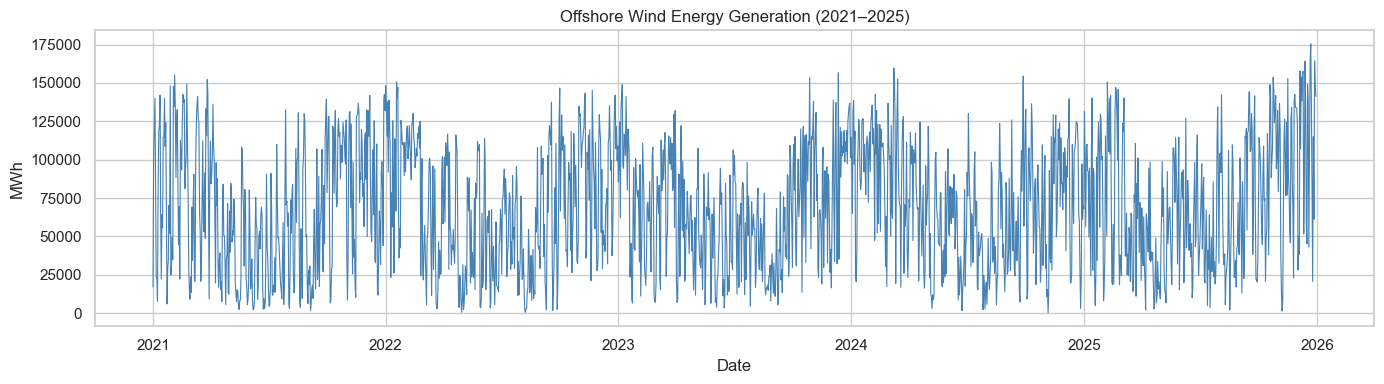

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["date"], df["generation_offshore_mwh"], color="steelblue", linewidth=0.8)
ax.set_title("Offshore Wind Energy Generation (2021–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("MWh")

plt.tight_layout()
plt.show()

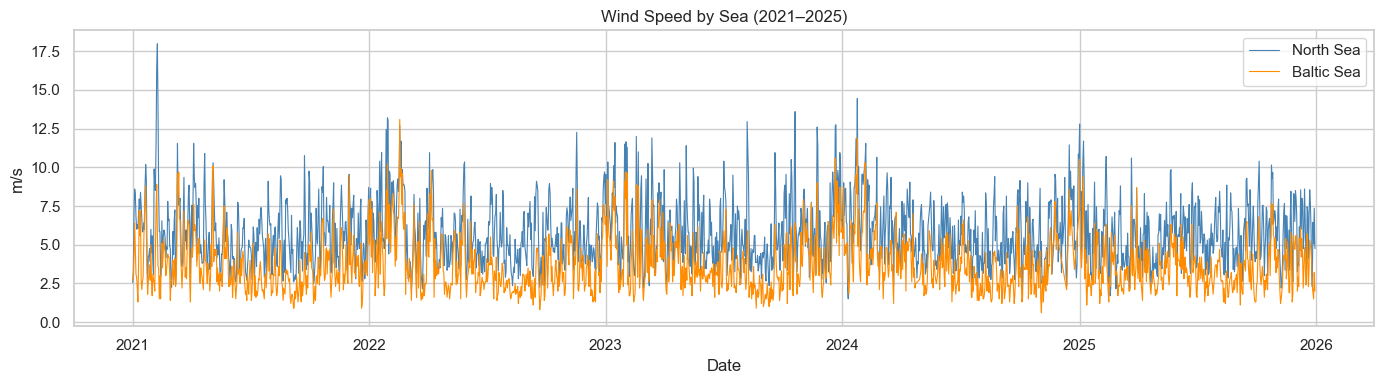

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["date"], df["wind_north_sea_ms"], color="steelblue", linewidth=0.8, label="North Sea")
ax.plot(df["date"], df["wind_baltic_ms"], color="darkorange", linewidth=0.8, label="Baltic Sea")

ax.set_title("Wind Speed by Sea (2021–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("m/s")
ax.legend()

plt.tight_layout()
plt.show()

Individual station detail for the North Sea: List auf Sylt is notably more exposed 
and records higher wind speeds than Helgoland.

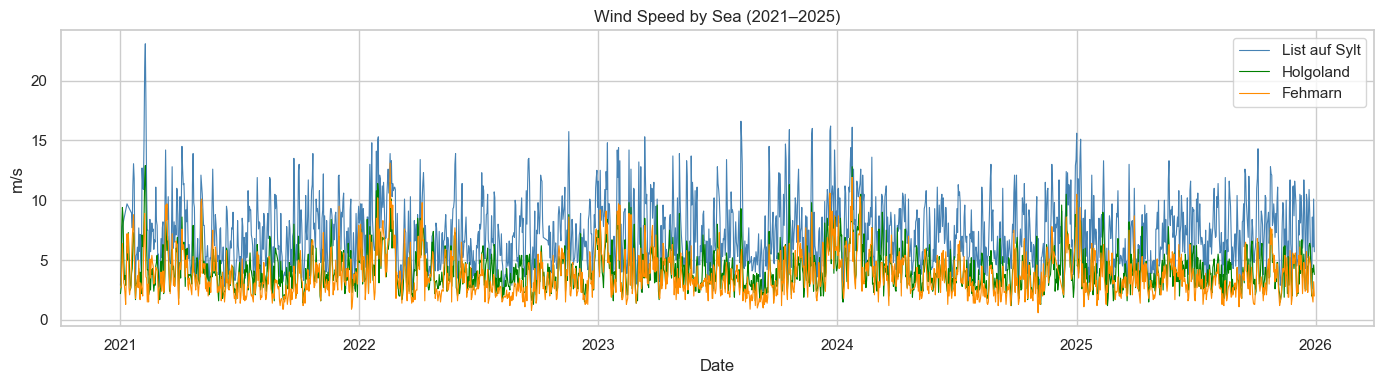

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["date"], df["wind_sylt_ms"], color="steelblue", linewidth=0.8, label="List auf Sylt")
ax.plot(df["date"], df["wind_helgoland_ms"], color="green", linewidth=0.8, label="Holgoland")
ax.plot(df["date"], df["wind_fehmarn_ms"], color="darkorange", linewidth=0.8, label="Fehmarn")

ax.set_title("Wind Speed by Sea (2021–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("m/s")
ax.legend()

plt.tight_layout()
plt.show()

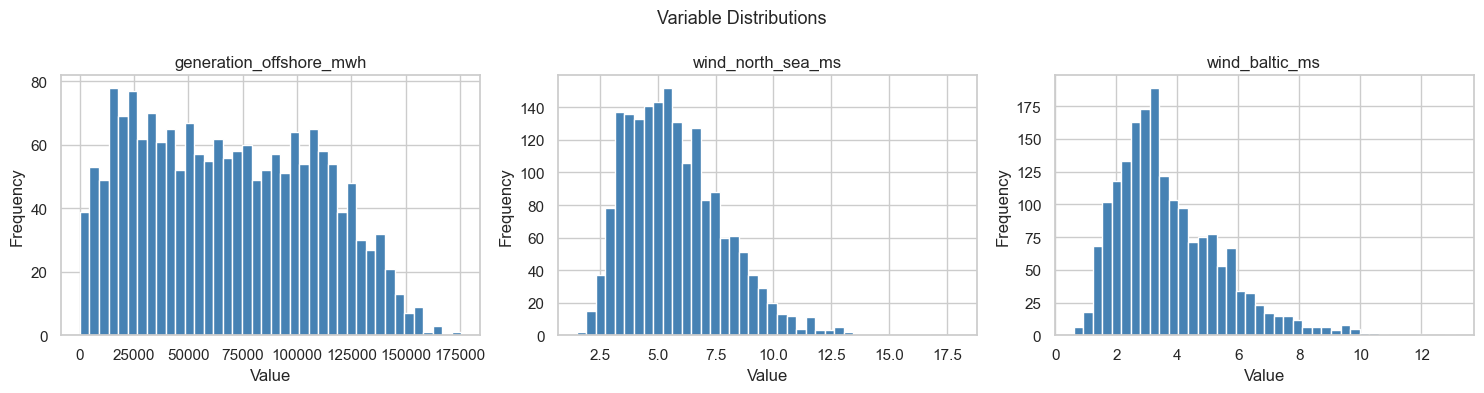

In [11]:
cols = ["generation_offshore_mwh", "wind_north_sea_ms", "wind_baltic_ms"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cols):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Variable Distributions", fontsize=13)
plt.tight_layout()
plt.show()

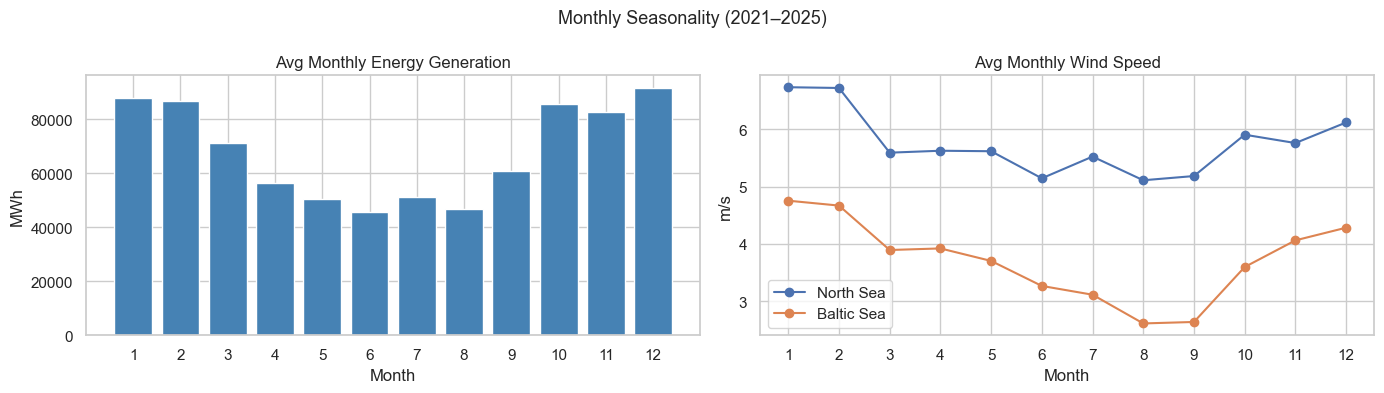

In [12]:
# --- Monthly seasonality ---
df["month"] = df["date"].dt.month

monthly_avg = df.groupby("month")[["generation_offshore_mwh", "wind_north_sea_ms", "wind_baltic_ms"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Energy
axes[0].bar(monthly_avg.index, monthly_avg["generation_offshore_mwh"], color="steelblue")
axes[0].set_title("Avg Monthly Energy Generation")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("MWh")
axes[0].set_xticks(range(1, 13))

# Wind
axes[1].plot(monthly_avg.index, monthly_avg["wind_north_sea_ms"], marker="o", label="North Sea")
axes[1].plot(monthly_avg.index, monthly_avg["wind_baltic_ms"], marker="o", label="Baltic Sea")
axes[1].set_title("Avg Monthly Wind Speed")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("m/s")
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.suptitle("Monthly Seasonality (2021–2025)", fontsize=13)
plt.tight_layout()
plt.show()